# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [2]:
!unzip /content/K4_ready_for_colab.zip -d /content/K4_Lab

Archive:  /content/K4_ready_for_colab.zip
   creating: /content/K4_Lab/code/
  inflating: /content/K4_Lab/code/results_table.py  
  inflating: /content/K4_Lab/code/model.py  
  inflating: /content/K4_Lab/code/optimizer.py  
  inflating: /content/K4_Lab/code/train.py  
  inflating: /content/K4_Lab/code/lab.ipynb  
  inflating: /content/K4_Lab/code/plots.py  
  inflating: /content/K4_Lab/code/data.py  
   creating: /content/K4_Lab/scripts/
  inflating: /content/K4_Lab/scripts/make_split_metadata.py  
  inflating: /content/K4_Lab/scripts/evaluate.py  
  inflating: /content/K4_Lab/scripts/split_data.py  
   creating: /content/K4_Lab/data/
  inflating: /content/K4_Lab/data/split_metadata.csv  
  inflating: /content/K4_Lab/data/README.md  
  inflating: /content/K4_Lab/README.md  
  inflating: /content/K4_Lab/GUIDE.md  
   creating: /content/K4_Lab/templates/
  inflating: /content/K4_Lab/templates/experiment_table_template.xlsx  
  inflating: /content/K4_Lab/templates/REPORT_TEMPLATE.md  


In [10]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

REPO_ROOT = "/content/K4_Lab"     # thư mục gốc repo (chứa data/ và scripts/)
OUT_DIR   = "/content/K4_Lab/submission_123456"        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv

# Thêm REPO_ROOT/code vào hệ thống để import các module local thành công trên Colab
sys.path.append(f"{REPO_ROOT}/code")

# TODO: chọn device ("cuda" nếu có GPU, ngược lại "cpu"; trên Mac có thể "mps"); in torch.__version__ và tên GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# TODO: os.makedirs cho f"{OUT_DIR}/figures" và f"{OUT_DIR}/results"
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch version: 2.11.0+cu130
Using device: cuda
GPU Name: Tesla T4


In [5]:
REPO_ROOT = "/content/K4_Lab"     # thư mục gốc repo (chứa data/ và scripts/)
OUT_DIR   = "/content/K4_Lab/submission_123456"        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv

## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [12]:
import subprocess
import sys
import os
import numpy as np
import torch
from data import prepare_data

os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/results', exist_ok=True)

print('Chạy split_data.py...')
# Thiết lập PYTHONPATH cho tiến trình con để có thể import các module trong thư mục code
env = os.environ.copy()
env['PYTHONPATH'] = f"{REPO_ROOT}/code:" + env.get('PYTHONPATH', '')

try:
    result = subprocess.run(
        [sys.executable, f'{REPO_ROOT}/scripts/split_data.py'],
        cwd=REPO_ROOT,
        env=env,
        capture_output=True,
        text=True,
        check=True
    )
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print("--- Lỗi khi chạy split_data.py ---")
    print("STDOUT:", e.stdout)
    print("STDERR:", e.stderr)
    raise e

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f'{REPO_ROOT}/data/processed')

print(f'X_tr shape: {data["X_tr"].shape}')
print(f'X_val shape: {data["X_val"].shape}')
print(f'X_eval shape: {data["X_eval"].shape}')

val_y = data['y_val'].cpu().numpy()
most_frequent_class = np.bincount(val_y).argmax()
baseline_acc = np.mean(val_y == most_frequent_class)
print(f'Accuracy đoán lớp đa số trên val: {baseline_acc:.4f}')

Chạy split_data.py...
train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876

Train size: 371847, Val size: 92962, Eval size: 116203
Majority class accuracy on val: 0.4876
X_tr shape: torch.Size([371847, 54])
X_val shape: torch.Size([92962, 54])
X_eval shape: torch.Size([116203, 54])
Accuracy đoán lớp đa số trên val: 0.4876


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

Số tham số hợp lệ: 47879
Shape đầu ra hợp lệ: torch.Size([8, 7])
Loss bước 0 ban đầu: 1.6443 (Kỳ vọng ~ 1.946)


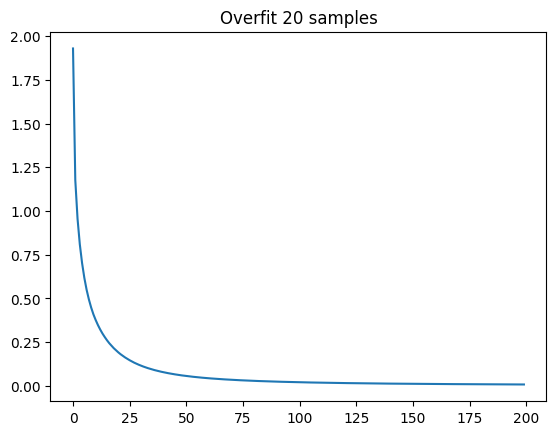

net.0.weight grad norm: 0.0114
net.0.bias grad norm: 0.0033
net.2.weight grad norm: 0.0184
net.2.bias grad norm: 0.0019
net.4.weight grad norm: 0.0147
net.4.bias grad norm: 0.0003


In [13]:
from model import MLP, EXPECTED_PARAMS, count_params
import torch.nn as nn

model = MLP(hidden=(256, 128), dropout=0.0, init='he').to(device)
assert count_params(model) == EXPECTED_PARAMS[(256,128)]
print('Số tham số hợp lệ:', count_params(model))

dummy_x = torch.randn(8, 54).to(device)
logits = model(dummy_x)
assert logits.shape == (8, 7)
print('Shape đầu ra hợp lệ:', logits.shape)

criterion = nn.CrossEntropyLoss()
loss = criterion(logits, torch.randint(0, 7, (8,)).to(device))
print(f'Loss bước 0 ban đầu: {loss.item():.4f} (Kỳ vọng ~ 1.946)')

import torch.optim as optim
import matplotlib.pyplot as plt

optimizer = optim.SGD(model.parameters(), lr=0.1)
x_mini = data['X_tr'][:20]
y_mini = data['y_tr'][:20]
losses = []
for _ in range(200):
    optimizer.zero_grad()
    out = model(x_mini)
    l = criterion(out, y_mini)
    l.backward()
    optimizer.step()
    losses.append(l.item())

plt.plot(losses)
plt.title('Overfit 20 samples')
plt.show()

for name, p in model.named_parameters():
    if p.grad is not None:
        print(f'{name} grad norm: {p.grad.norm().item():.4f}')
        assert p.grad.norm().item() > 0


**Nhận xét Part 1 (tự viết):** loss bước 0 đo được = ___, so với ln 7 = 1.946 vì sao ...; quá khớp 20 mẫu: ...

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [14]:
from train import DEFAULT_CFG, run_experiment
from results_table import save_result
from plots import plot_run

cfg = DEFAULT_CFG.copy()
cfg['lr'] = 0.05
cfg['epochs'] = 20

val_macros = []
val_accs = []
for s in [42, 43, 44]:
    exp_cfg = {**cfg, 'seed': s, 'exp_id': f'base-s{s}', 'group': 'baseline'}
    res = run_experiment(exp_cfg, data)
    save_result(res, f'{OUT_DIR}/results')
    plot_run(res, f'{OUT_DIR}/figures/{exp_cfg["exp_id"]}.png')
    val_macros.append(res['summary']['val_macro_f1'])
    val_accs.append(res['summary']['val_acc'])

print(f'Val Macro-F1 (Baseline): {np.mean(val_macros):.4f} ± {np.std(val_macros):.4f}')
print(f'Val Acc (Baseline): {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}')


Val Macro-F1 (Baseline): 0.8375 ± 0.0082
Val Acc (Baseline): 0.9030 ± 0.0004


**Nhận xét baseline (tự viết):** hình dạng đường cong (còn giảm? bắt đầu quá khớp?), val_acc so với mốc "đoán đa số", độ nhiễu giữa các seed ...

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `<exp_id>` — chủ đề `<nhóm>`
**Dự đoán trước (viết TRƯỚC khi chạy):** ...

In [15]:
experiments = [
    {'exp_id': 'adam-lr1e-3', 'group': 'optimizer', 'description': 'Adam lr 0.001', 'optimizer': 'adam', 'lr': 0.001},
    {'exp_id': 'adamw-lr1e-3', 'group': 'optimizer', 'description': 'AdamW lr 0.001', 'optimizer': 'adamw', 'lr': 0.001},
    {'exp_id': 'model-wide', 'group': 'architecture', 'description': 'Wide model', 'hidden': (512, 256)},
    {'exp_id': 'model-deep', 'group': 'architecture', 'description': 'Deep model', 'hidden': (256, 128, 64)},
]

for exp in experiments:
    print(f'Running {exp["exp_id"]}...')
    exp_cfg = {**DEFAULT_CFG, **exp, 'seed': 42}
    res = run_experiment(exp_cfg, data)
    save_result(res, f'{OUT_DIR}/results')
    plot_run(res, f'{OUT_DIR}/figures/{exp_cfg["exp_id"]}.png')
    print(f'Done {exp["exp_id"]}: Val F1 = {res["summary"]["val_macro_f1"]:.4f}')


Running adam-lr1e-3...
Done adam-lr1e-3: Val F1 = 0.8496
Running adamw-lr1e-3...
Done adamw-lr1e-3: Val F1 = 0.8496
Running model-wide...
Done model-wide: Val F1 = 0.8788
Running model-deep...
Done model-deep: Val F1 = 0.8687


**Đối chiếu sau khi chạy:** khớp / khác dự đoán? vì sao (cơ chế)? chênh lệch có vượt 2σ không? ...

In [16]:
from results_table import load_results
from plots import plot_compare
results_all = load_results(f'{OUT_DIR}/results')
opt_results = [r for r in results_all if r['cfg'].get('group') in ['optimizer', 'baseline']]
arch_results = [r for r in results_all if r['cfg'].get('group') in ['architecture', 'baseline']]

plot_compare(opt_results, 'val_loss', f'{OUT_DIR}/figures/compare_optimizer.png')
plot_compare(arch_results, 'val_loss', f'{OUT_DIR}/figures/compare_architecture.png')


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [18]:
from train import final_eval
best_cfg = {**DEFAULT_CFG, 'exp_id': 'adamw-lr1e-3', 'optimizer': 'adamw', 'lr': 0.001, 'seed': 42}
best_res = run_experiment(best_cfg, data)
final_eval(best_cfg, best_res, data, f'{OUT_DIR}/predictions_eval.csv')

import subprocess
import os
import sys

env = os.environ.copy()
env['PYTHONPATH'] = f"{REPO_ROOT}/code:" + env.get('PYTHONPATH', '')

try:
    result = subprocess.run([
        sys.executable, f'{REPO_ROOT}/scripts/evaluate.py',
        '--pred', f'{OUT_DIR}/predictions_eval.csv',
        '--out', f'{OUT_DIR}/eval_result.json'
    ], cwd=REPO_ROOT, env=env, capture_output=True, text=True, check=True)
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print("--- Lỗi khi chạy evaluate.py ---")
    print("STDOUT:", e.stdout)
    print("STDERR:", e.stderr)
    raise e

Đã lưu kết quả tại /content/K4_Lab/submission_123456/predictions_eval.csv. Chạy thủ công: python scripts/evaluate.py --pred /content/K4_Lab/submission_123456/predictions_eval.csv
n_eval = 116203
accuracy = 0.9027
macro_f1 = 0.8470   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9024  0.9050  0.9037
  1    56661     0.9130  0.9244  0.9187
  2     7151     0.8809  0.8747  0.8778
  3      549     0.7804  0.8415  0.8098
  4     1899     0.7305  0.7651  0.7474
  5     3473     0.8280  0.7029  0.7603
  6     4102     0.9583  0.8684  0.9111

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38345   3779     1    0    96    15   132
1   3607  52377   112    0   389   153    23
2      1    453  6255   97    40   305     0
3      0      0    67  462     0    20     0
4     29    389    14    0  1453    14     0
5     20    316   652   33    11  2441     0
6    488     52     0    0     0     0  3562

đã ghi /content/K4_Lab/

In [21]:
import json
with open(f'{OUT_DIR}/eval_result.json', 'r') as f:
    eval_res = json.load(f)
print('Macro F1:', eval_res['macro_f1'])
print('Accuracy:', eval_res['accuracy'])

# Lấy F1 score của từng lớp từ danh sách 'per_class'
f1_scores = [round(cls['f1'], 4) for cls in eval_res['per_class']]
print('F1 by class:', f1_scores)

Macro F1: 0.8469813387764912
Accuracy: 0.9026875381874823
F1 by class: [0.9037, 0.9187, 0.8778, 0.8098, 0.7474, 0.7603, 0.9111]


**Phân tích lỗi (tự viết):** ...

In [26]:
import json
from results_table import load_results, to_row, write_xlsx

results = load_results(f'{OUT_DIR}/results')

# Đọc dữ liệu eval_result.json thành dictionary
eval_scores = None
eval_path = f'{OUT_DIR}/eval_result.json'
if os.path.exists(eval_path):
    with open(eval_path, 'r') as f:
        eval_scores = json.load(f)

rows = []
for r in results:
    is_best = (r['cfg']['exp_id'] == 'adamw-lr1e-3')
    # Truyền dictionary (hoặc None) thay vì truyền đường dẫn chuỗi
    rows.append(to_row(r, eval_scores=eval_scores if is_best else None))

write_xlsx(rows, f'{REPO_ROOT}/templates/experiment_table_template.xlsx', f'{OUT_DIR}/experiments.xlsx')
print('Done writing Excel.')

Done writing Excel.


In [27]:
import shutil

# Định nghĩa đường dẫn file zip đầu ra
zip_output_path = f"{REPO_ROOT}/submission_123456"

# Tiến hành nén thư mục OUT_DIR thành file .zip
shutil.make_archive(zip_output_path, 'zip', OUT_DIR)
print(f"Đã đóng gói thành công file: {zip_output_path}.zip")

Đã đóng gói thành công file: /content/K4_Lab/submission_123456.zip
